#**Name - Sujit Kumar Padhan**
#**Batch No - 501**

#**Project Title**:
**Stroke Prediction using Machine Learning**

#**Problem Statement:**
**Stroke is one of the leading causes of death and disability worldwide. Early prediction of stroke risk can help healthcare professionals take preventive actions and reduce mortality. The aim of this project is to develop a machine learning model that predicts whether a patient is likely to experience a stroke based on demographic and health-related information.**

#**Business Objective:**
- Predict whether a patient is likely to have a stroke.
- Identify the most important risk factors affecting stroke.
- Help healthcare providers take preventive actions at an early stage.

**Target Variable**

In [ ]:
#stroke
# 0 = No Stroke

# 1 = Stroke

**Import Libraries:**

In [ ]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset :**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/healthcare-dataset-stroke-data.csv")

**First Five Records:**

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Observation**
- Dataset loaded successfully.
- Each row represents one patient's medical record.

**Shape:**

In [ ]:
df.shape

(5110, 12)

**Observation**
- Dataset contains 5110 rows.
- Dataset contains 12 columns

**Column Names:**

In [ ]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

**Dataset Information:**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


**Observation**
- Dataset contains numerical and categorical variables.
- BMI contains missing values.
- Stroke is the target variable.

**Data Types:**

In [ ]:
df.dtypes

,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


**Observation:**
- Dataset contains

    - Integer Columns
    - Float Columns
    - Object Columns

**Statistical Summary (Numerical):**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


**Observation:**
- Average age is around 43 years.
- Average glucose level is approximately 106.
- BMI values vary considerably, indicating possible outliers.

**Statistical Summary (Categorical):**

In [ ]:
df.describe(include='O').T

,count,unique,top,freq
gender,5110,3,Female,2994
ever_married,5110,2,Yes,3353
work_type,5110,5,Private,2925
Residence_type,5110,2,Urban,2596
smoking_status,5110,4,never smoked,1892


**Observation:**
- Majority of patients are married.
- Most patients work in the Private sector.
- Most patients live in Urban areas.

**Missing Values:**

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


**Observation**
- Missing values are present only in the BMI column.
- Other columns have no missing values.

**Duplicate Values:**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Observation:**
- No duplicate records found.

**Check Target Variable:**

In [ ]:
df["stroke"].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
df["stroke"].value_counts(normalize=True)*100

,proportion
stroke,
0,95.127202
1,4.872798


**Observation**
- Majority of patients do not have stroke.
- Stroke class is highly imbalanced.

**Recommendation:**
- SMOTE will be applied before model training.

**Drop ID Column:**

In [ ]:
df.drop("id",axis=1,inplace=True)

**Observation**

- ID is only a unique identifier.

- It has no contribution in prediction.

- Therefore it is removed.

In [ ]:
df.shape

(5110, 11)

**Separate Target Variable:**

In [ ]:
X=df.drop("stroke",axis=1)

y=df["stroke"]

**Numerical Columns:**

In [ ]:
num_cols=X.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

**Categorical Columns:**

In [ ]:
cat_cols=X.select_dtypes(include=["object"]).columns.tolist()
cat_cols

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

**Observation:**
- Numerical and categorical features are identified separately.

**Target Variable Distribution:**

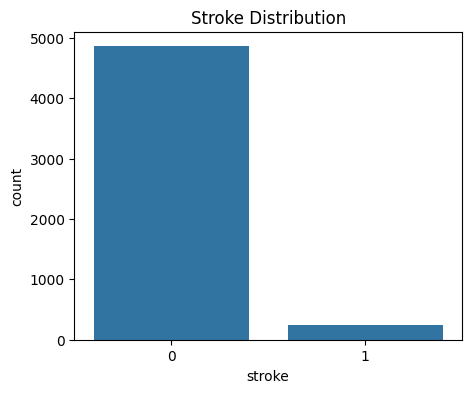

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='stroke', data=df)
plt.title("Stroke Distribution")
plt.show()

**Observation**
- Majority of patients belong to class 0 (No Stroke).
- Very few patients belong to class 1 (Stroke).

**Insight**
- Dataset is highly imbalanced.

**Gender Distribution**

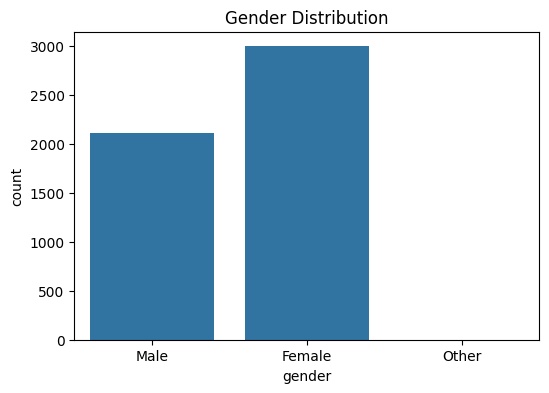

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

**Observation**
- Female records are slightly higher than Male records.
- Other category contains very few records.

**Insight**
- Gender distribution is almost balanced.

**Age Distribution:**

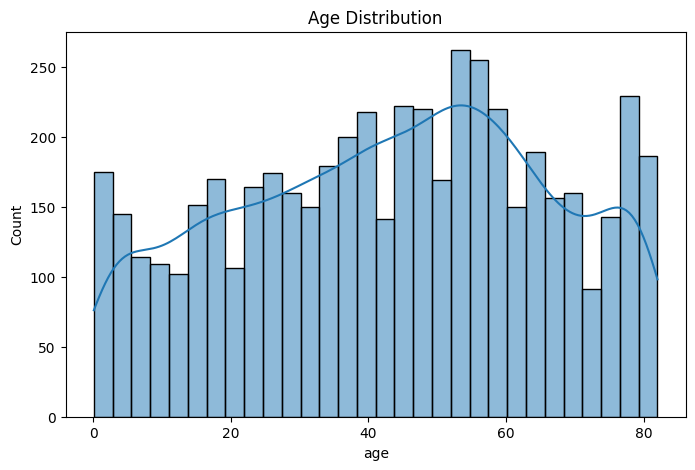

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

**Observation**
- Most patients belong to the age group of 40–60 years.
- Fewer observations belong to younger age groups.

**Insight**
- Stroke risk generally increases with age.

**BMI Distribution:**

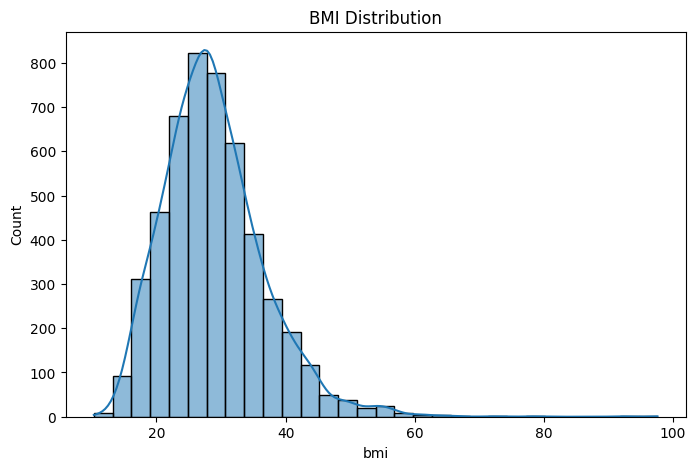

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=30, kde=True)
plt.title("BMI Distribution")
plt.show()

**Observation**
- BMI is positively skewed.
- Some extreme BMI values are present.

Average Glucose Level Distribution:

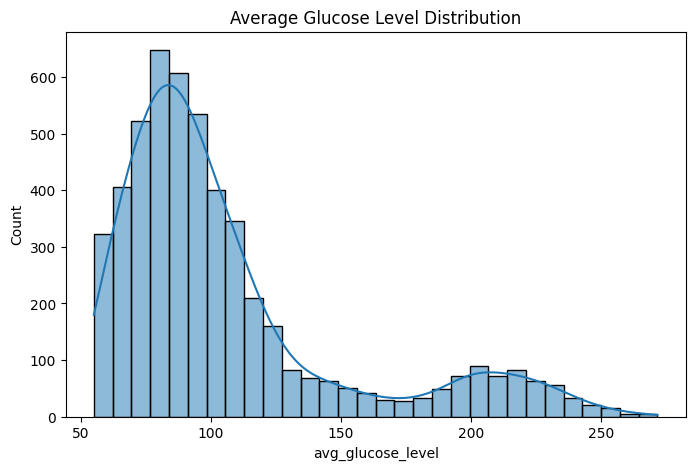

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['avg_glucose_level'], bins=30, kde=True)
plt.title("Average Glucose Level Distribution")
plt.show()

**Observation**
- Distribution is right-skewed.
- Few patients have extremely high glucose levels.

**Insight**
- High glucose levels may increase stroke risk.

**Hypertension Distribution:**

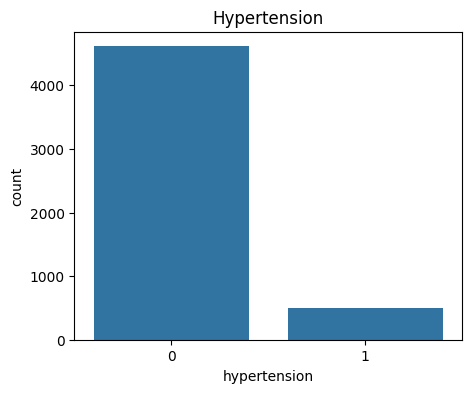

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='hypertension', data=df)
plt.title("Hypertension")
plt.show()

**Observation**
- Most patients do not have hypertension.

**Heart Disease Distribution:**

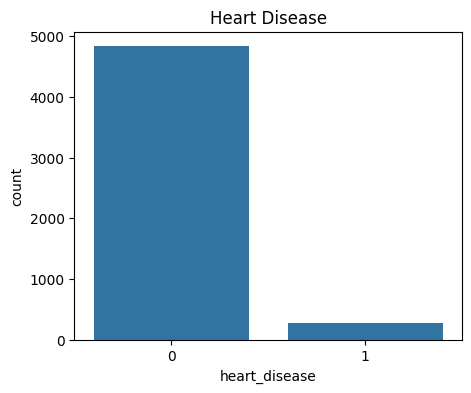

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='heart_disease', data=df)
plt.title("Heart Disease")
plt.show()

**Observation**
- Majority of patients do not have heart disease.

**Smoking Status:**

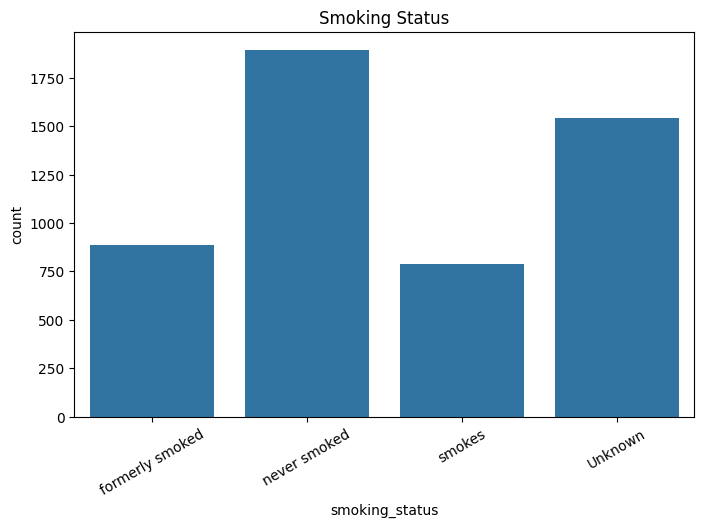

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='smoking_status', data=df)
plt.xticks(rotation=30)
plt.title("Smoking Status")
plt.show()

**Observation**
- Most patients never smoked.
- Many records have "Unknown" smoking status.

**Work Type:**

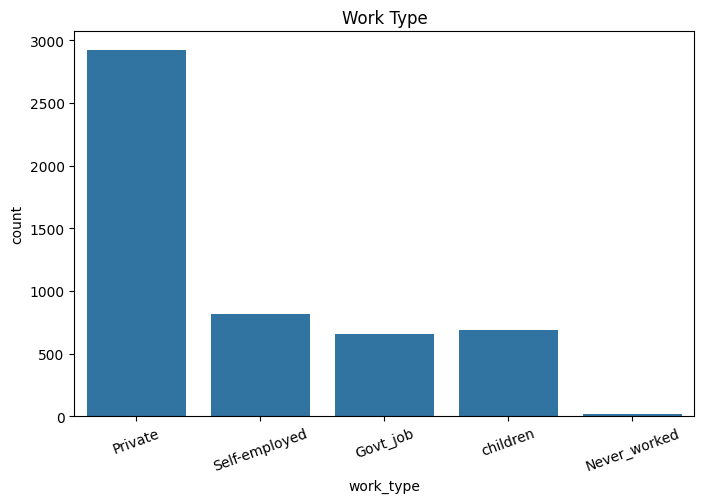

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='work_type', data=df)
plt.xticks(rotation=20)
plt.title("Work Type")
plt.show()

**Observation**
- Most patients work in the Private sector.

**Residence Type:**

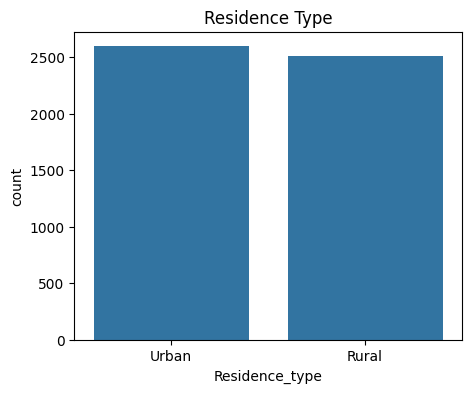

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='Residence_type', data=df)
plt.title("Residence Type")
plt.show()

**Observation**
- Urban and Rural populations are nearly balanced.

**Boxplot (Outlier Detection):**

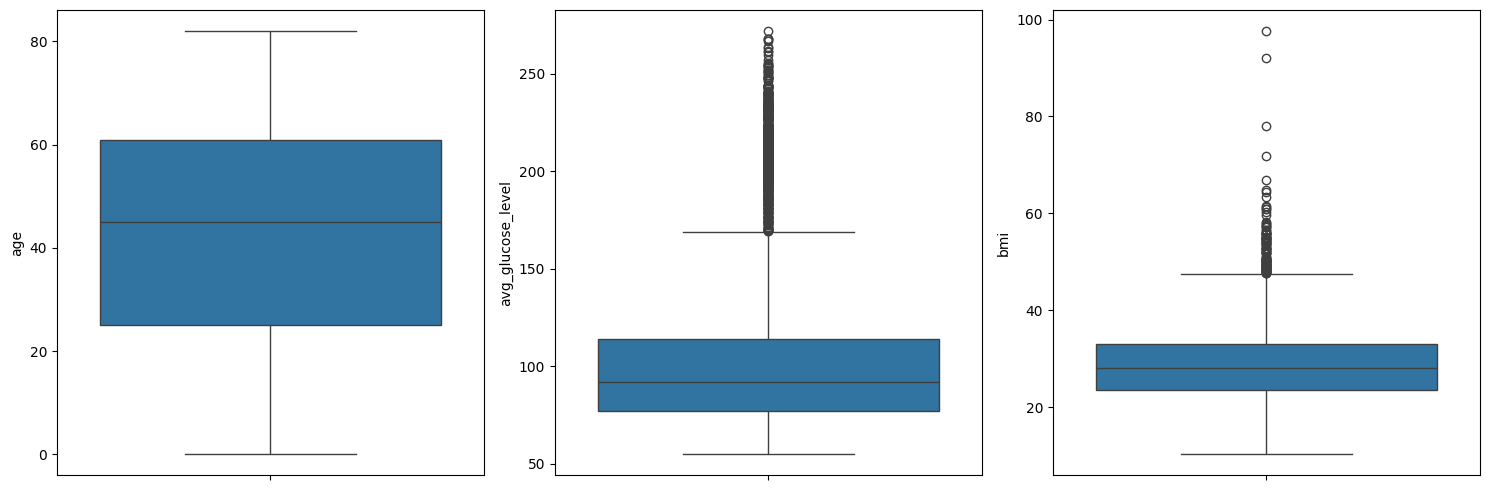

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['age'])

plt.subplot(1,3,2)
sns.boxplot(y=df['avg_glucose_level'])

plt.subplot(1,3,3)
sns.boxplot(y=df['bmi'])

plt.tight_layout()
plt.show()

**Observation**
- Age contains very few outliers.
- Average glucose level contains several outliers.
- BMI also contains outliers.

**Correlation Heatmap:**

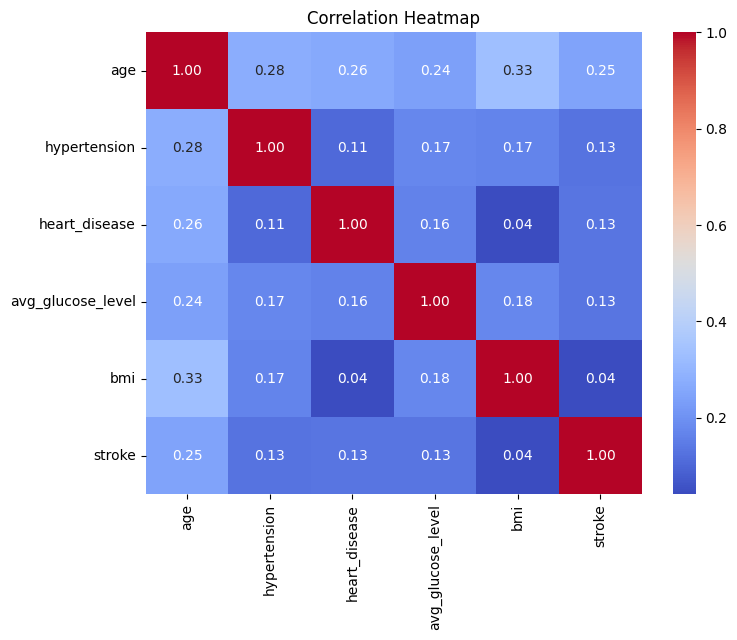

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[num_cols +['stroke']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

**Observation**
- Age has a positive correlation with stroke.
- Hypertension and heart disease are positively correlated with stroke.
- BMI has weak correlation.

**Insight**
- Age, hypertension, and heart disease are important predictors.

**Stroke vs Age:**

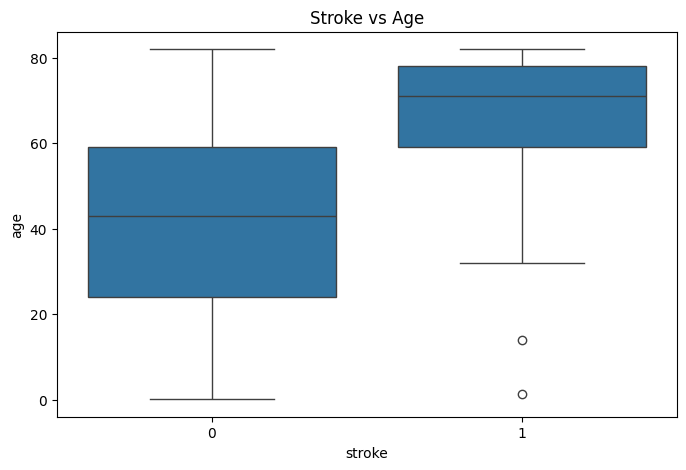

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='age', data=df)
plt.title("Stroke vs Age")
plt.show()

**Observation**
- Patients with stroke are generally older.

**Insight**
- Age is a significant risk factor.

**Stroke vs Glucose:**

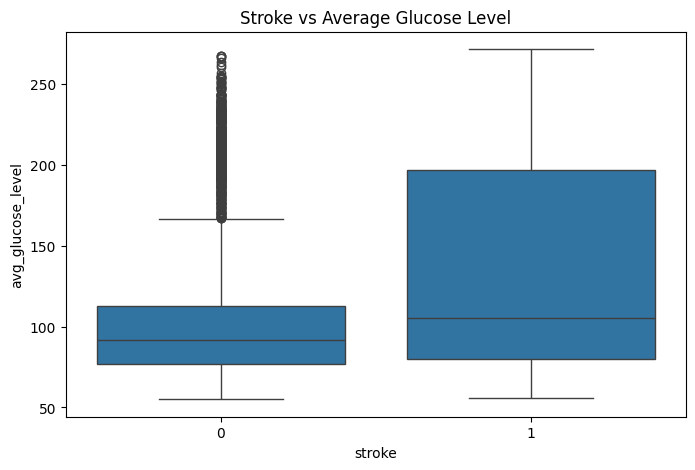

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.title("Stroke vs Average Glucose Level")
plt.show()

**Observation**

- Stroke patients tend to have higher glucose levels.

**Stroke vs BMI:**

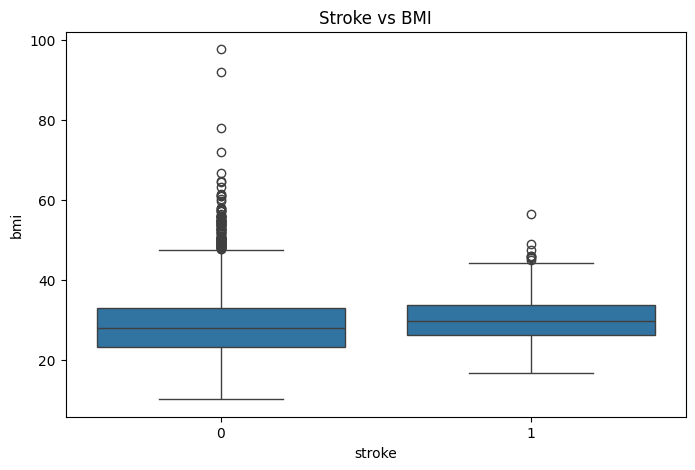

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='bmi', data=df)
plt.title("Stroke vs BMI")
plt.show()

**Observation**
- BMI does not show a strong difference between stroke and non-stroke patients.

**Train Test Split:**

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
#check shape
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4088, 10)
(1022, 10)
(4088,)
(1022,)


**Observation**
- 80% Training Data
- 20% Testing Data

**Numerical Pipeline:**

In [ ]:
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

**Observation**
- Median fills missing values.
- StandardScaler scales numerical features

**Categorical Pipeline:**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown='ignore'))
])

**Observation**
- Missing values replaced using most frequent category.
- Label Encoding converts categorical variables into numeric format.

**Column Transformer:**

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num",num_pipeline,num_cols),
    ("cat",cat_pipeline,cat_cols)
])

**Observation**
- Numerical preprocessing and categorical preprocessing are combined into a single transformer.

**SMOTE:**

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", KNeighborsClassifier())
])

**Observation**
- SMOTE balances the minority class only on the training folds during model training.

#**Model Building & Hyperparameter Tuning:**

In [ ]:
from sklearn.model_selection import GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.feature_selection import SelectKBest, f_classif

#**KNN:**

In [ ]:
#Pipeline
knn_pipeline = ImbPipeline([
    ("preprocessor",preprocessor),
    ("smote",SMOTE(random_state=42)),
    ("classifier",KNeighborsClassifier())
])
#Parameters
param_grid_knn = {
    "classifier__n_neighbors":[3,5,7,9]
}
#Grid Search
grid_knn = GridSearchCV(
    knn_pipeline,
    param_grid_knn,
    cv=5,
    scoring="accuracy"
)

grid_knn.fit(X_train,y_train)

print("Best Parameters :",grid_knn.best_params_)
print("Best Accuracy :",grid_knn.best_score_)

Best Parameters : {'classifier__n_neighbors': 3}
Best Accuracy : 0.8483380367675885


**Observation**
- GridSearchCV automatically selects the best value of K.
- KNN is sensitive to feature scaling, which is handled by the pipeline.

#**Naive Bayes:**

In [ ]:
#Pipeline
nb_pipeline = ImbPipeline([
    ("preprocessor",preprocessor),
    ("smote",SMOTE(random_state=42)),
    ("feature_selection",SelectKBest(score_func=f_classif)),
    ("classifier",GaussianNB())
])
#Parameters
import numpy as np

param_grid_nb = {

    "feature_selection__k":[5,7,9,"all"],

    "classifier__var_smoothing":np.logspace(0,-9,10)

}
#Grid Search
grid_nb = GridSearchCV(
    nb_pipeline,
    param_grid_nb,
    cv=5,
    scoring="accuracy"
)

grid_nb.fit(X_train,y_train)

print("Best Parameters :",grid_nb.best_params_)
print("Best Accuracy :",grid_nb.best_score_)

Best Parameters : {'classifier__var_smoothing': np.float64(1.0), 'feature_selection__k': 7}
Best Accuracy : 0.8148261425155543


**Observation**
- Naive Bayes assumes feature independence.
- Feature selection improves performance.

**Store Best Models:**

In [ ]:
best_models = {
     "KNN":grid_knn.best_estimator_,
     "Naive Bayes":grid_nb.best_estimator_
}

**Observation:**
- Two classification models were trained.
- Hyperparameter tuning was performed using GridSearchCV.
- SMOTE was applied to handle class imbalance.
- Pipelines ensured consistent preprocessing for all models.

**Model Evaluation:**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)
results = []
for name, model in best_models.items():

    # Prediction
    y_pred = model.predict(X_test)

    # Probability (ROC-AUC ke liye)
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc = roc_auc_score(y_test,y_prob)

    # Store Results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

    print("="*60)
    print("Model :",name)
    print("="*60)

    print("Accuracy :",accuracy)
    print("Precision :",precision)
    print("Recall :",recall)
    print("F1 Score :",f1)
    print("ROC AUC :",roc)

    print("\nClassification Report\n")

    print(classification_report(y_test,y_pred))

Model : KNN
Accuracy : 0.8581213307240705
Precision : 0.16260162601626016
Recall : 0.3225806451612903
F1 Score : 0.21621621621621623
ROC AUC : 0.6423891129032259

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       960
           1       0.16      0.32      0.22        62

    accuracy                           0.86      1022
   macro avg       0.56      0.61      0.57      1022
weighted avg       0.91      0.86      0.88      1022

Model : Naive Bayes
Accuracy : 0.815068493150685
Precision : 0.18407960199004975
Recall : 0.5967741935483871
F1 Score : 0.2813688212927757
ROC AUC : 0.8309307795698925

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.83      0.89       960
           1       0.18      0.60      0.28        62

    accuracy                           0.82      1022
   macro avg       0.58      0.71      0.59      1022
weighted avg       0.92

**Observation**
- Accuracy tells the overall correct predictions.
- Precision indicates how many predicted stroke cases are actually stroke.
- Recall shows how many actual stroke cases were correctly identified.
- F1 Score balances Precision and Recall.
- ROC-AUC measures the model's discrimination ability.

**Confusion Matrix:**

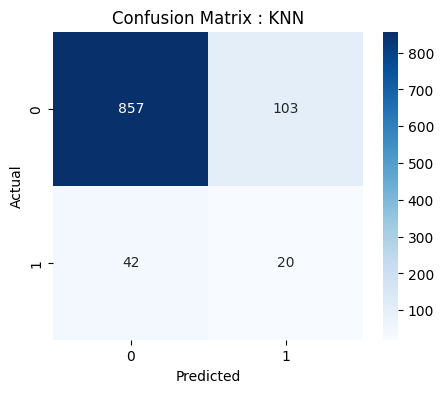

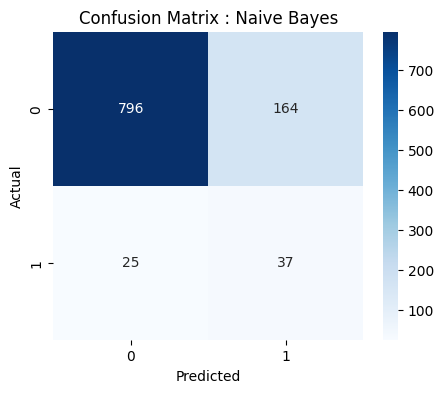

In [ ]:
for name, model in best_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test,y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix : {name}")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

**Observation**
- Diagonal values represent correct predictions.
- Off-diagonal values represent incorrect predictions.

**ROC-AUC:**

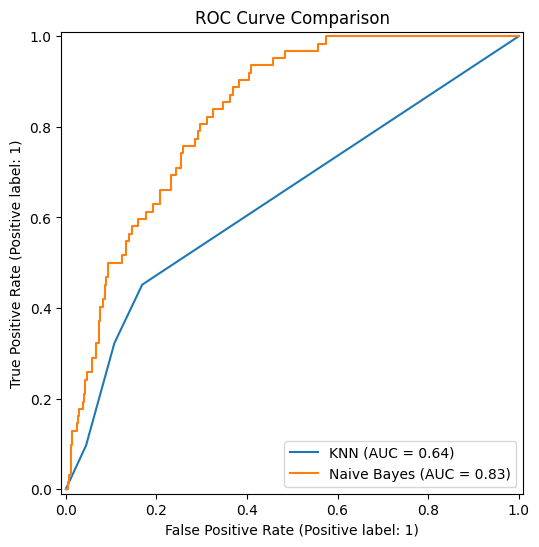

In [ ]:
plt.figure(figsize=(8,6))

for name, model in best_models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=plt.gca()
    )

plt.title("ROC Curve Comparison")

plt.show()

**Observation**
- Curves closer to the top-left corner indicate better performance.
- Higher ROC-AUC values indicate better classification ability.

**Model Comparison Table:**

In [ ]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]

)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,KNN,0.858121,0.162602,0.322581,0.216216,0.642389
1,Naive Bayes,0.815068,0.184080,0.596774,0.281369,0.830931


**Best Model:**

In [ ]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :",best_model_name)

Best Model : KNN


**Observations**
- Two machine learning models were evaluated.
- Accuracy, Precision, Recall, F1 Score, and ROC-AUC were calculated.
- Confusion Matrix and ROC Curve were used for visual evaluation.
- Model comparison table was created.
- KNN is the Best Model .

In [ ]:
# Select Best Model
best_model = grid_knn.best_estimator_

print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease',
                                                   'avg_glucose_level',
                                                   'bmi']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                               

**Model Save:**

In [ ]:
import joblib

joblib.dump(best_model, "stroke_prediction_model.pkl")

['stroke_prediction_model.pkl']

**Save Preprocessor:**

In [ ]:
joblib.dump(preprocessor,"preprocessor.pkl")

['preprocessor.pkl']

**Save Numerical Columns:**

In [ ]:
joblib.dump(num_cols,"num_cols.pkl")

['num_cols.pkl']

**Save Categorical Columns:**

In [ ]:
joblib.dump(cat_cols,"cat_cols.pkl")

['cat_cols.pkl']

**Load Saved Model:**

In [ ]:
loaded_model = joblib.load("stroke_prediction_model.pkl")

**Prediction on New Data:**

In [ ]:
new_patient = pd.DataFrame({

    "gender":["Male"],
    "age":[90],
    "hypertension":[1],
    "heart_disease":[1],
    "ever_married":["Yes"],
    "work_type":["Private"],
    "Residence_type":["Urban"],
    "avg_glucose_level":[220],
    "bmi":[36.5],
    "smoking_status":["formerly smoked"]

})

In [ ]:
prediction = loaded_model.predict(new_patient)[0]
probability = loaded_model.predict_proba(new_patient)[0]

print("Prediction:", prediction)

Prediction: 1
